# Import Functions

In [1]:
import numpy as np
import pandas as pd

from IPython.display import Image
np.set_printoptions(suppress=True)

# Helper Functions

In [2]:
def augment_matrix(A, y):
    """Augments matrix A and vector y."""
    if A.shape[0] != y.shape[0]:
        raise ValueError(f'{A.shape[0]} not matching {y.shape[0]}')
    
    return np.c_[A, y]

def _ero1(A, i1, i2, verbose=True):
    """Performs elementary row operation I."""
    print(f'ERO1: R{i1} <-> R{i2}') if verbose else None
    A_ = A.copy()
    A_[[i1, i2]] = A_[[i2, i1]]
    return A_

def _ero2(A, i, k, verbose=True):
    """Performs elementary row operation II."""
    print(f'ERO2: R{i} <- {k} x R{i}') if verbose else None
    A_ = A.copy()
    A_[i] = k * A_[i]
    return A_

def _ero3(A, i1, i2, k, verbose=True):
    """Performs elementary row operation III."""
    print(f'ERO3: R{i1} <- R{i1} + {k} x R{i2}') if verbose else None
    A_ = A.copy()
    A_[i1] = A_[i1] + A_[i2] * k
    return A_

def rref(A, verbose=False, display_round=4):
    """Transforms augmented matrix A to its Reduced Row Echelon Form."""
    A_ = A.copy()
    rows = A.shape[0]

    for i in range(rows):

        if verbose:
            print(f'\nRow {i} (FROM)')
            print(np.round(A_, display_round))

        imax = np.argmax(np.abs(A_[i:, i]))+i
        A_ = _ero1(A_, i, imax, verbose)
        if A_[i, i] == 0:
            continue
        A_ = _ero2(A_, i, 1/A_[i, i], verbose)
        A_[i, i] = 1.0

        for j in range(rows):
            if j != i:
                k = A_[j, i]
                if k != 0:
                    A_ = _ero3(A_, j, i, -k, verbose)
        if verbose:
            print(f'Row {i} (TO)')
            print(np.round(A_, display_round))

    return A_


# Setting up Matrix from Input and Outputs

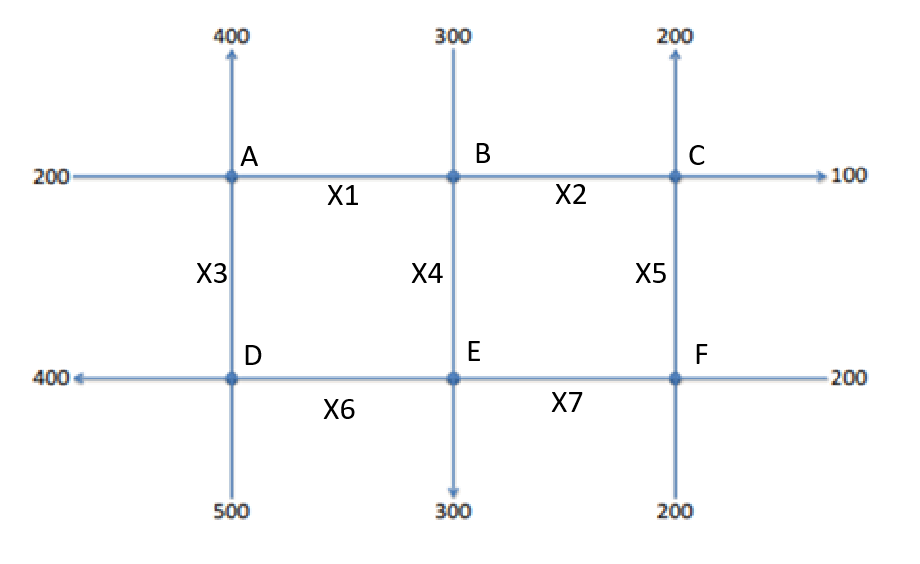

In [13]:
Image("images/labeled_street.png", width=500, height=300)


\begin{array}{|c|c|c|c|}
\hline
\textbf{NODE} & \textbf{INPUT} & \textbf{OUTPUT} & \textbf{EQUATION} \\
\hline
A & 200 + X_3 & 400 + X_1 & X_1 - X_3 = -200 \\
B & 300 + X_1 & X_2 + X_4 & X_2 + X_4 - X_1 = 300 \\
C & X_2 + X_5 & 200 + 100 & X_2 + X_5 = 300 \\
D & X_6 + 500 & X_3 + 400 & X_3 - X_6 = 100 \\
E & X_4 + X_7 & X_6 + 300 & X_4 + X_7 - X_6 = 300 \\
F & 200 + 200 & X_5 + X_7 & X_5 + X_7 = 400 \\
\hline
\end{array}


## Matrix Representation


$\left[
\begin{array}{rrrrrrr|r}
1 & 0 & -1 & 0 & 0 & 0 & 0 & -200 \\
-1 & 1 & 0 & 1 & 0 & 0 & 0 & 300 \\
0 & 1 & 0 & 0 & 1 & 0 & 0 & 300 \\
0 & 0 & 1 & 0 & 0 & -1 & 0 & 100 \\
0 & 0 & 0 & 1 & 0 & -1 & 1 & 300 \\
0 & 0 & 0 & 0 & 1 & 0 & 1 & 400 \\
\end{array}
\right]$



In [4]:
A = np.array([
    [1, 0, -1, 0, 0, 0, 0],
    [-1, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, -1, 0],
    [0, 0, 0, 1, 0, -1, 1],
    [0, 0, 0, 0, 1, 0, 1],
], dtype=float)

y = np.array([-200, 300, 300, 100, 300, 400])

Below is the augmented matrix.

In [5]:
Ay = augment_matrix(A, y)
Ay

array([[   1.,    0.,   -1.,    0.,    0.,    0.,    0., -200.],
       [  -1.,    1.,    0.,    1.,    0.,    0.,    0.,  300.],
       [   0.,    1.,    0.,    0.,    1.,    0.,    0.,  300.],
       [   0.,    0.,    1.,    0.,    0.,   -1.,    0.,  100.],
       [   0.,    0.,    0.,    1.,    0.,   -1.,    1.,  300.],
       [   0.,    0.,    0.,    0.,    1.,    0.,    1.,  400.]])

To solve the SLE problem, the augmented matrix is transformed to an RREF. The exact step by step solution of the different elementary row operations can be seen here.

In [6]:
Ay_rref = rref(Ay, verbose=True)


Row 0 (FROM)
[[   1.    0.   -1.    0.    0.    0.    0. -200.]
 [  -1.    1.    0.    1.    0.    0.    0.  300.]
 [   0.    1.    0.    0.    1.    0.    0.  300.]
 [   0.    0.    1.    0.    0.   -1.    0.  100.]
 [   0.    0.    0.    1.    0.   -1.    1.  300.]
 [   0.    0.    0.    0.    1.    0.    1.  400.]]
ERO1: R0 <-> R0
ERO2: R0 <- 1.0 x R0
ERO3: R1 <- R1 + 1.0 x R0
Row 0 (TO)
[[   1.    0.   -1.    0.    0.    0.    0. -200.]
 [   0.    1.   -1.    1.    0.    0.    0.  100.]
 [   0.    1.    0.    0.    1.    0.    0.  300.]
 [   0.    0.    1.    0.    0.   -1.    0.  100.]
 [   0.    0.    0.    1.    0.   -1.    1.  300.]
 [   0.    0.    0.    0.    1.    0.    1.  400.]]

Row 1 (FROM)
[[   1.    0.   -1.    0.    0.    0.    0. -200.]
 [   0.    1.   -1.    1.    0.    0.    0.  100.]
 [   0.    1.    0.    0.    1.    0.    0.  300.]
 [   0.    0.    1.    0.    0.   -1.    0.  100.]
 [   0.    0.    0.    1.    0.   -1.    1.  300.]
 [   0.    0.    0.    0.    

In [7]:
print(Ay_rref)

[[   1.    0.    0.    0.    0.   -1.    0. -100.]
 [   0.    1.    0.    0.    0.    0.   -1. -100.]
 [   0.    0.    1.    0.    0.   -1.    0.  100.]
 [   0.    0.    0.    1.    0.   -1.    1.  300.]
 [   0.    0.    0.    0.    1.    0.    1.  400.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]]


## A. Is it possible to close off one or several of the roads? If so, which onces can or cannot be closed. What happens to the traffic flow when this happens?

Given that $X_i≥0$ on all roads, in which constraints to having only positive flow rates on each road. We can see in the reduced row echelon form of the matrix that the columns of $X_6$ and $X_7$ are both free variables that represent non-pivotal columns. 

Let $X_6=S_1$ and $X_7=S_2$

$$
X = \begin{bmatrix} 
x_1 \\
x_2 \\
x_3 \\
x_4 \\
x_5 \\
x_6 \\
x_7 \\
\end{bmatrix}
=
\begin{bmatrix}
-100 \\
-100 \\
100 \\
300 \\
400 \\
0 \\
0 \\
\end{bmatrix}
+
\begin{bmatrix}
1 \\
0 \\
1 \\
1 \\
0 \\
1 \\
0 \\
\end{bmatrix}
s_1
+
\begin{bmatrix}
0 \\
1 \\
0 \\
-1 \\
-1 \\
0 \\
1 \\
\end{bmatrix}
s_2 \\

$$

Constraints are as follows.

$$
\begin{aligned}
-100 + s_1 &\geq 0 \quad &\Rightarrow \quad s_1 &\geq 100 \\
-100 + s_2 &\geq 0 \quad &\Rightarrow \quad s_2 &\geq 100 \\
100 + s_1 &\geq 0 \quad &\Rightarrow \quad s_1 &\geq -100 \\
300 + s_1 - s_2 &\geq 0 \quad &\Rightarrow \quad 300 &\geq s_2 - s_1 \\
400 - s_2 &\geq 0 \quad &\Rightarrow \quad s_2 &\leq 400 \\
s_1 &\geq 0 \\
s_2 &\geq 0 \\
\end{aligned}
$$

Constraints can be summarized as follows:
$$
\begin{aligned}
400 &\geq s_2 &\geq 100 \\
s_1 &\geq 100 
\end{aligned}
$$


By applying these constraints, the flow ranges for each road become:

$$
\begin{aligned}
x_1 &\geq 0 \\
300 &\geq x_2 &\geq 0 \\
x_3 &\geq 200 \\
300 &\geq x_4 &\geq 0 \\
300 &\geq x_5 &\geq 0 \\
x_6 &\geq 100 \\
400 &\geq x_7 &\geq 100 \\
\end{aligned}
$$


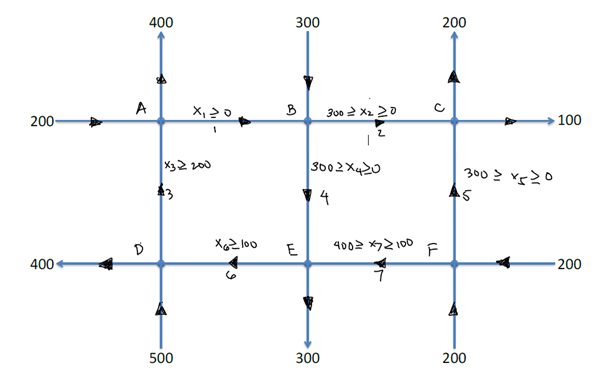

In [14]:
Image("images/streetwithconstraints.png", width=500, height=300)

Based on the solution, the roads that can be closed are $X_1$, $X_2$, $X_4$, and $X_5$ as flow rate of 0 is allowed for them. 

There are four possible scenarios for the mention roads: 

- One is if $X_1$ is closed, the distribution will become \
$[X_1, X_2,  X_3,  X_4,  X_5,  X_6,  X_7]^T=[0, 0, 200, 300, 300, 100, 100]^T$

- Second, if $X_2$ is closed, then the new matrix will be \
$[X_1,  X_2,  X_3,  X_4,  X_5,  X_6,  X_7]^T=[0, 0, 200, 300, 300, 100, 100]^T$

- Third, if $X_4$ is closed, the distribution will become \
$[X_1,  X_2,  X_3,  X_4,  X_5,  X_6,  X_7]^T=[0, 300, 200, 0, 0, 100, 400]^T$

- Lastly, if $X_5$ is closed, then the new matrix will be \
$[X_1,  X_2,  X_3,  X_4,  X_5,  X_6,  X_7]^T=[0, 300, 200, 0, 0, 100, 400]^T$

Closing these roads will just redivert some of the traffic towards other roads. Note that while these 4 roads can be closed, not all of them can be closed simultaneously. For example, if we allow roads $X_1$, $X_2$, and $X_4$ to be closed at the same time, then the cars having 300 flow rates will have no other route for exit. See figure below.


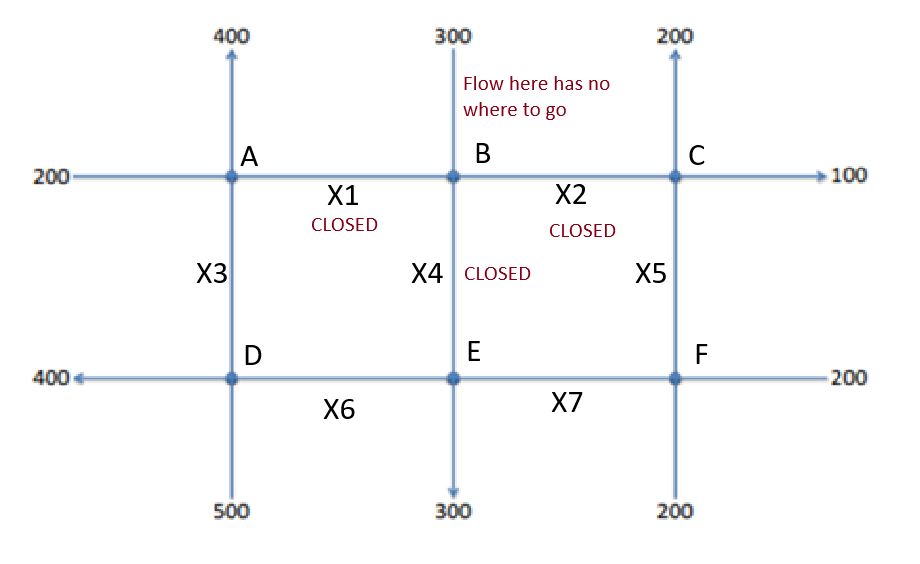

In [15]:
Image("images/manyclosedcase.png", width=500, height=300)

We can also observe that some roads cannot be closed such as roads $X_3$, $X_6$, and $X_7$.  If we close road $X_3$, then no other route would lead to an exit flow rate of 400.


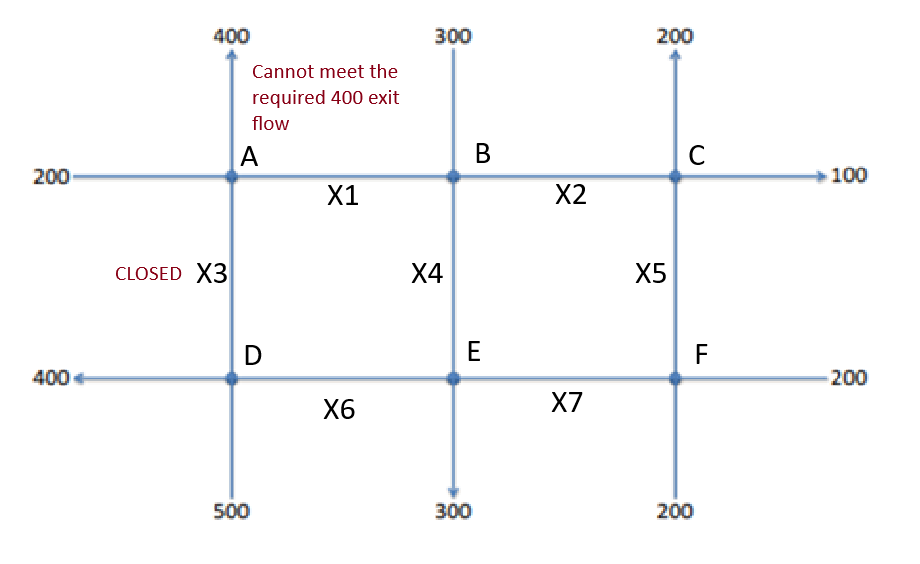

In [16]:
Image("images/x3closedcase.png", width=500, height=300)

For the case of road $X_6$, closing it would make the excess traffic at node D going to road $X_3$ not fast enough to meet the required exit flow rate of 400 at node A since it would not allow $X_3$ to meet its required flow.

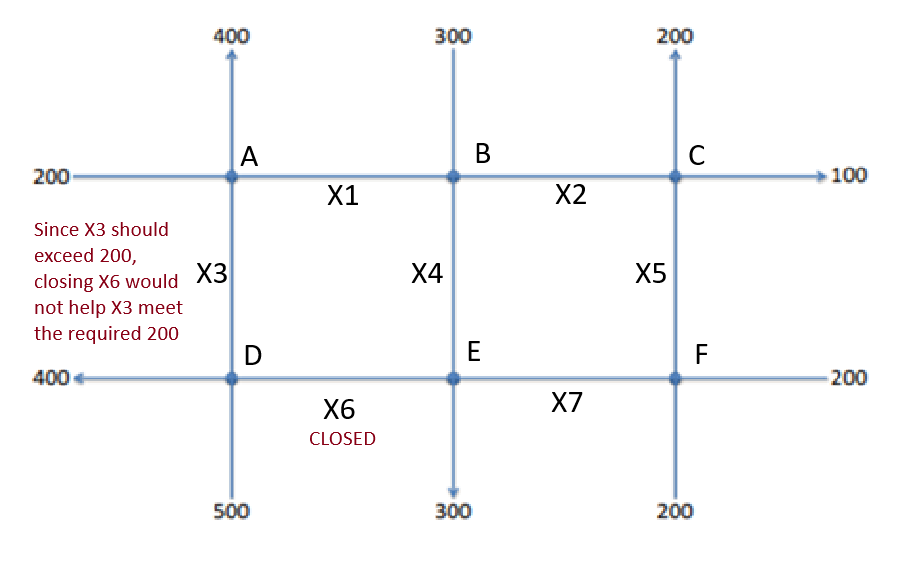

In [17]:
Image("images/x6closedcase.png", width=500, height=300)

## B. If traffic is diverted by closing off some of the roads (this is down by installing diverting signs at the beginning of each road), how many such signs are needed?

Again, while we can possibly close 4 roads, at a given instant, we can safely close 2 roads at most (as shown from the 2 free variables that we have). If we allow $S_1=100$ and $S_2=100$, then this makes roads 1 and 2 be closed and the others having non-zero flows. Another case is if $S_1=100$ and $S_2=400$ which closes roads 1 and 5. This makes us required to have 2 diverting signs to close the stated 2 rows.

## C. Can we have a restriction of no more than 200 cares in a particular street?

It is safe to say that roads $X_1$, $X_3$ and $X_6$ can handle a maximum of 200 cars. Meanwhile, the roads $X_2$, $X_4$, $X_5$ and $X_7$ cannot simultaneously be restricted to the threshold without disrupting the flow. In doing so, the right part of the segment will not be able to maintain the 200 cars on specific nodes C, E and F.